In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
df = pd.read_csv('sales_data.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1048575, 6)

Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

First 5 rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,01-01-2013,1,AUTOMOTIVE,0.0,0
1,1,01-01-2013,1,BABY CARE,0.0,0
2,2,01-01-2013,1,BEAUTY,0.0,0
3,3,01-01-2013,1,BEVERAGES,0.0,0
4,4,01-01-2013,1,BOOKS,0.0,0


In [7]:
# Parse date and sort
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')

# Aggregate sales by month
df['Month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

print("Monthly Sales Shape:", monthly_sales.shape)
monthly_sales.tail()

Monthly Sales Shape: (20, 2)


,Month,sales
15,2014-04-01,1.286125e+07
16,2014-05-01,1.337979e+07
17,2014-06-01,1.331996e+07
18,2014-07-01,1.942189e+07
19,2014-08-01,5.693305e+06


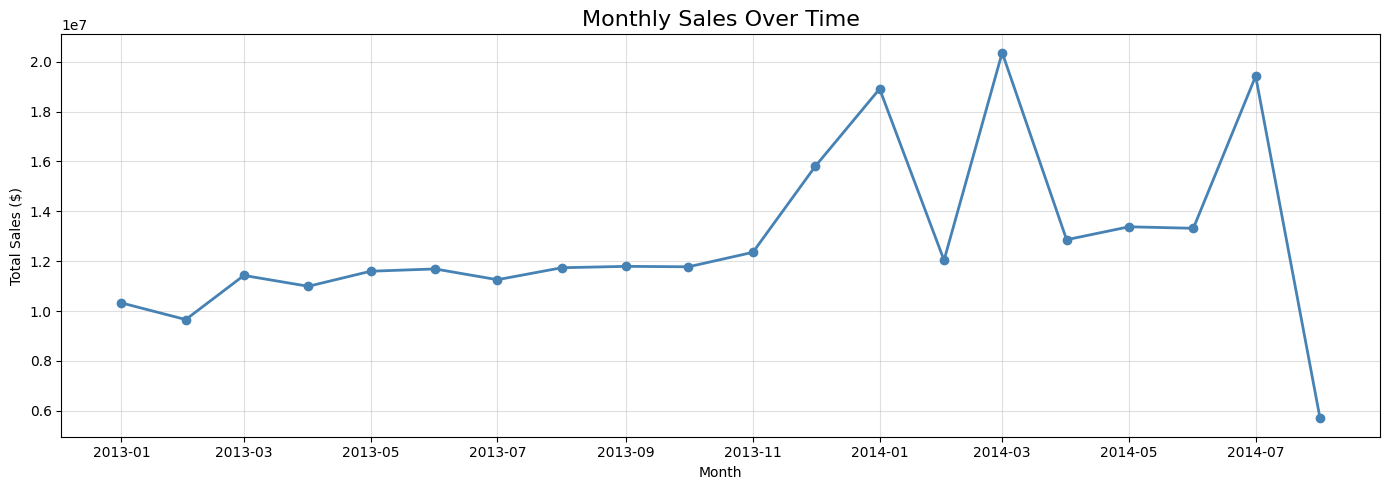

✅ Sales trend plotted!


In [8]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month'], monthly_sales['sales'],
         marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('sales_trend.png')
plt.show()
print("✅ Sales trend plotted!")

In [9]:
# Use last 6 months as test set
split = int(len(monthly_sales) * 0.8)
train = monthly_sales[:split]
test  = monthly_sales[split:]

print(f"Train size: {len(train)} months")
print(f"Test size:  {len(test)} months")

Train size: 16 months
Test size:  4 months


In [10]:
train_idx = np.arange(len(train)).reshape(-1, 1)
test_idx  = np.arange(len(train), len(monthly_sales)).reshape(-1, 1)

lr = LinearRegression()
lr.fit(train_idx, train['sales'])

lr_preds = lr.predict(test_idx)

mae  = mean_absolute_error(test['sales'], lr_preds)
rmse = np.sqrt(mean_squared_error(test['sales'], lr_preds))

print(f"Linear Regression → MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f}")

Linear Regression → MAE: $5,173,396.64 | RMSE: $6,518,366.16


In [12]:
model = ExponentialSmoothing(
    train['sales'],
    trend='add',
    seasonal=None,      # ← removed seasonal (not enough data)
    initialization_method='estimated'
)
fit = model.fit()
es_preds = fit.forecast(len(test))

mae_es  = mean_absolute_error(test['sales'], es_preds)
rmse_es = np.sqrt(mean_squared_error(test['sales'], es_preds))

print(f"Exponential Smoothing → MAE: ${mae_es:,.2f} | RMSE: ${rmse_es:,.2f}")

Exponential Smoothing → MAE: $4,817,540.03 | RMSE: $6,029,418.79


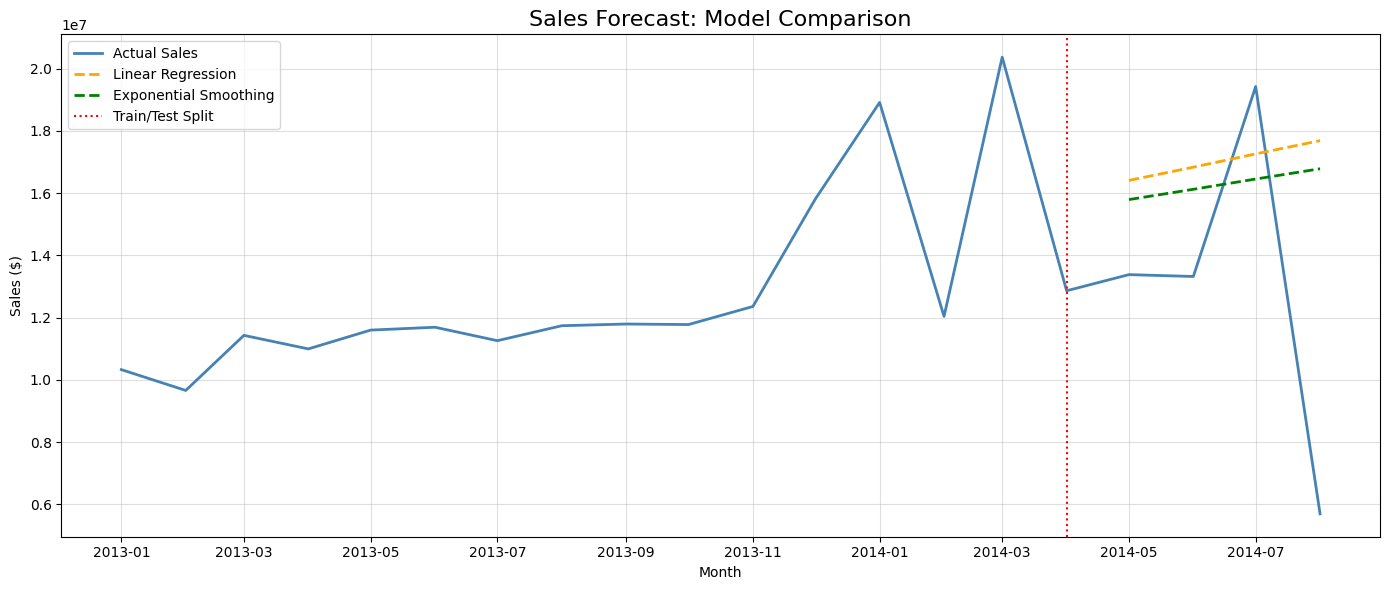

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month'], monthly_sales['sales'],
         label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(test['Month'], lr_preds,
         label='Linear Regression', color='orange',
         linestyle='--', linewidth=2)
plt.plot(test['Month'], es_preds.values,
         label='Exponential Smoothing', color='green',
         linestyle='--', linewidth=2)
plt.axvline(x=train['Month'].iloc[-1], color='red',
            linestyle=':', label='Train/Test Split')
plt.title('Sales Forecast: Model Comparison', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_comparison.png')
plt.show()

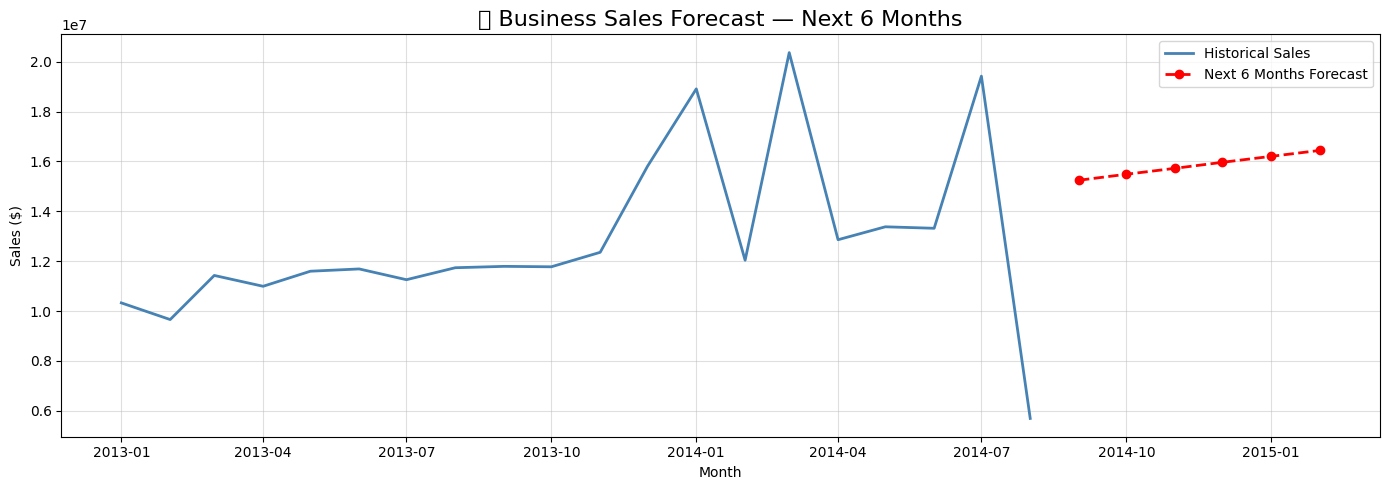


📊 Forecasted Sales for Next 6 Months:
  September 2014: $15,247,493.57
  October 2014: $15,486,979.11
  November 2014: $15,726,464.66
  December 2014: $15,965,950.20
  January 2015: $16,205,435.74
  February 2015: $16,444,921.29


In [14]:
future_model = ExponentialSmoothing(
    monthly_sales['sales'],
    trend='add',
    seasonal=None,      # ← same fix here
    initialization_method='estimated'
).fit()

future_preds = future_model.forecast(6)
last_date = monthly_sales['Month'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=7, freq='MS')[1:]

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month'], monthly_sales['sales'],
         label='Historical Sales', color='steelblue', linewidth=2)
plt.plot(future_dates, future_preds.values,
         label='Next 6 Months Forecast', color='red',
         linestyle='--', marker='o', linewidth=2)
plt.title('📈 Business Sales Forecast — Next 6 Months', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('future_forecast.png')
plt.show()

print("\n📊 Forecasted Sales for Next 6 Months:")
for date, val in zip(future_dates, future_preds.values):
    print(f"  {date.strftime('%B %Y')}: ${val:,.2f}")
    

In [15]:
print("=" * 50)
print("       📋 BUSINESS INSIGHTS SUMMARY")
print("=" * 50)
print(f"Total Historical Sales:  ${monthly_sales['sales'].sum():,.2f}")
print(f"Average Monthly Sales:   ${monthly_sales['sales'].mean():,.2f}")
print(f"Peak Sales Month:        {monthly_sales.loc[monthly_sales['sales'].idxmax(), 'Month'].strftime('%B %Y')}")
print(f"Best Model:              {'Exp. Smoothing' if mae_es < mae else 'Linear Regression'}")
print(f"Forecast RMSE (best):    ${min(rmse_es, rmse):,.2f}")
print("=" * 50)

       📋 BUSINESS INSIGHTS SUMMARY
Total Historical Sales:  $256,410,781.77
Average Monthly Sales:   $12,820,539.09
Peak Sales Month:        March 2014
Best Model:              Exp. Smoothing
Forecast RMSE (best):    $6,029,418.79
